In [1]:
from openpilot.tools.lib.route import Route
from openpilot.tools.lib.logreader import LogReader
import folium
import pandas as pd

kj/filesystem-disk-unix.c++:1734: warning: PWD environment variable doesn't match current directory; pwd = /home/linux


In [2]:
lr = LogReader("/home/linux/Documents/nanocda/wifi/00000013--afae3eb23b--0/rlog.zst")

In [3]:
# Extract GPS data from LogReader
gps_data = []
for msg in lr:
    if msg.which() == 'gpsLocationExternal':
        gps = msg.gpsLocationExternal
        gps_data.append({
            'timestamp': msg.logMonoTime,
            'latitude': gps.latitude,
            'longitude': gps.longitude,
            'altitude': gps.altitude,
            'speed': gps.speed,
        })

# Convert to DataFrame for easier handling
gps_df = pd.DataFrame(gps_data)
print(f"Found {len(gps_df)} GPS points")

# Create map centered on first GPS point
if len(gps_df) > 0:
    center_lat = gps_df['latitude'].mean()
    center_lon = gps_df['longitude'].mean()

    # Create folium map
    m = folium.Map(location=[center_lat, center_lon], zoom_start=15)

    # Add GPS track as a line
    coordinates = [[row['latitude'], row['longitude']] for _, row in gps_df.iterrows()]
    folium.PolyLine(coordinates, color='red', weight=3, opacity=0.8).add_to(m)

    # Add start and end markers
    folium.Marker(
        [gps_df.iloc[0]['latitude'], gps_df.iloc[0]['longitude']],
        popup='Start',
        icon=folium.Icon(color='green')
    ).add_to(m)

    folium.Marker(
        [gps_df.iloc[-1]['latitude'], gps_df.iloc[-1]['longitude']],
        popup='End',
        icon=folium.Icon(color='red')
    ).add_to(m)

    # Save map to HTML file for viewing
    map_file = 'gps_map.html'
    m.save(map_file)
    print(f"Map saved to {map_file} - open this file in a web browser to view the interactive map")

    # Display map in notebook (may not work in all environments)
    from IPython.display import display
    display(m)

else:
    print("No GPS data found in the log")

Found 389 GPS points
Map saved to gps_map.html - open this file in a web browser to view the interactive map


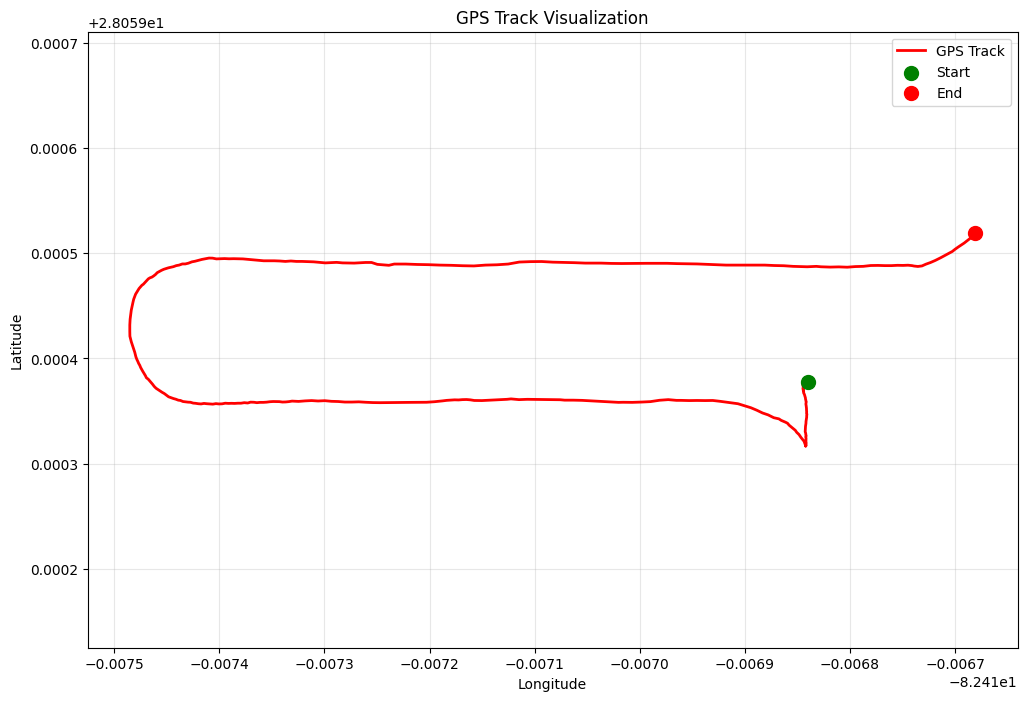

Total distance: 389 GPS points
Lat range: 28.059317 to 28.059519
Lon range: -82.417485 to -82.416681
Max speed: 5.4 m/s


In [4]:
# Alternative matplotlib visualization for VSCode
import matplotlib.pyplot as plt

if len(gps_df) > 0:
    plt.figure(figsize=(12, 8))
    plt.plot(gps_df['longitude'], gps_df['latitude'], 'r-', linewidth=2, label='GPS Track')
    plt.scatter(gps_df.iloc[0]['longitude'], gps_df.iloc[0]['latitude'],
                color='green', s=100, label='Start', zorder=5)
    plt.scatter(gps_df.iloc[-1]['longitude'], gps_df.iloc[-1]['latitude'],
                color='red', s=100, label='End', zorder=5)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('GPS Track Visualization')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

    # Print some basic stats
    print(f"Total distance: {len(gps_df)} GPS points")
    print(f"Lat range: {gps_df['latitude'].min():.6f} to {gps_df['latitude'].max():.6f}")
    print(f"Lon range: {gps_df['longitude'].min():.6f} to {gps_df['longitude'].max():.6f}")
    if 'speed' in gps_df.columns:
        print(f"Max speed: {gps_df['speed'].max():.1f} m/s")
else:
    print("No GPS data available for plotting")